In [1]:
import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures"],
    highs=[15000, 4000],
    lows=[1000, 500],
    reset_previous=True,
)
if "I__hvgs" not in ds.RNA.feats.columns:
    ds.mark_hvgs(
        min_cells=20,
        top_n=500,
        show_plot=False,
    )

In [2]:
normalized = ds.run_normalization(feat_key="hvgs")
pca = ds.run_pca(normalized, dims=15)
initialization = ds.build_embedding_initialization(
    pca,
    n_centroids=100,
)
ann_index = ds.build_ann_index(pca)
neighbors = ds.query_neighbors(ann_index, k=11)
graph = ds.build_connectivity_map(neighbors)
graph

ArtifactRef(assay='RNA', kind='connectivity_map', artifact_id='5f7593c78d22...')

In [3]:
loaded_graph = ds.load_graph()
loaded_graph.shape, loaded_graph.nnz

((4360, 4360), 47960)

In [4]:
state = ds.get_assay_state("RNA")
{
    "cell selection": state.cell_key,
    "feature selection": state.feat_key,
    "normalization": state.normalized,
    "reduction": state.reduction,
    "neighbours": state.neighbors,
    "connectivity": state.connectivity_map,
}

{'cell selection': 'I',
 'feature selection': 'hvgs',
 'normalization': ArtifactRef(assay='RNA', kind='normalized', artifact_id='8e4557298dbd...'),
 'reduction': ArtifactRef(assay='RNA', kind='reduction', artifact_id='cf4982a6fe9f...'),
 'neighbours': ArtifactRef(assay='RNA', kind='neighbors', artifact_id='d4270f0b9fb6...'),
 'connectivity': ArtifactRef(assay='RNA', kind='connectivity_map', artifact_id='5f7593c78d22...')}

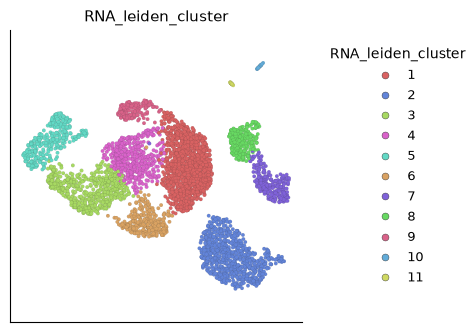

In [5]:
ds.run_umap(
    n_epochs=100,
    parallel=True,
)
ds.run_leiden_clustering(resolution=0.5)
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="RNA_leiden_cluster",
)

In [6]:
neighbors_k21 = ds.query_neighbors(
    ann_index,
    k=21,
    update_state=False,
)
graph_k21 = ds.build_connectivity_map(
    neighbors_k21,
    update_state=False,
)

current_state = ds.get_assay_state("RNA")
current_state.connectivity_map == graph, graph_k21 != graph

(True, True)